<a href="https://colab.research.google.com/github/khadija2027/Medical-image-classification-using-QCNN/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from medmnist import PneumoniaMNIST
import medmnist
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
import torch
from collections import Counter
from torchvision import transforms

In [6]:
!pip install medmnist -q

drive.mount('/content/drive', force_remount=True)
root = '/content/drive/MyDrive/medmnist_data'

train_dataset = PneumoniaMNIST(split="train", download=True)
val_dataset   = PneumoniaMNIST(split="val", download=True)
test_dataset  = PneumoniaMNIST(split="test", download=True)

Mounted at /content/drive


**1. DATASET OVERVIEW**

In [14]:
# 1. Define transform
transform = transforms.Compose([
    transforms.ToTensor(),  # PIL -> Tensor (C, H, W)
])

# 2. Load datasets with transform
train_dataset = PneumoniaMNIST(split="train", download=True, size=28, transform=transform)
val_dataset = PneumoniaMNIST(split="val", download=True, size=28, transform=transform)
test_dataset = PneumoniaMNIST(split="test", download=True, size=28, transform=transform)

# 3. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

# 4. Get all data
train_data, train_labels = next(iter(train_loader))
val_data, val_labels = next(iter(val_loader))
test_data, test_labels = next(iter(test_loader))

# Convert to numpy for easier manipulation
train_data_np = train_data.numpy()
train_labels_np = train_labels.numpy().flatten()
val_data_np = val_data.numpy()
val_labels_np = val_labels.numpy().flatten()
test_data_np = test_data.numpy()
test_labels_np = test_labels.numpy().flatten()

# 5. Verify
print(f"Training set size: {len(train_dataset)} images")
print(f"Validation set size: {len(val_dataset)} images")
print(f"Test set size: {len(test_dataset)} images")
print(f"Image shape: {train_data_np[0].shape}")

Training set size: 4708 images
Validation set size: 524 images
Test set size: 624 images
Image shape: (1, 28, 28)


**Class Distribution**

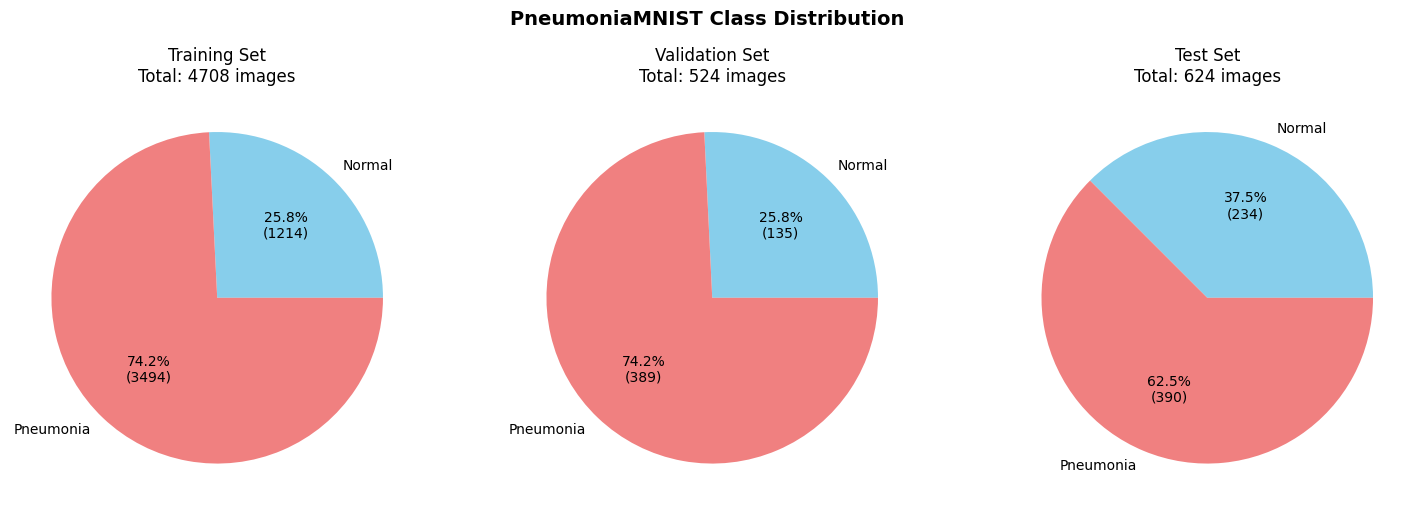

In [20]:
def plot_class_distribution_simple(train_labels, val_labels, test_labels):
    label_names = ['Normal', 'Pneumonia']
    colors = ['skyblue', 'lightcoral']

    # Get counts
    train_counts = [Counter(train_labels)[0], Counter(train_labels)[1]]
    val_counts = [Counter(val_labels)[0], Counter(val_labels)[1]]
    test_counts = [Counter(test_labels)[0], Counter(test_labels)[1]]

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot each pie chart
    for ax, (counts, title) in zip(axes, [
        (train_counts, 'Training Set'),
        (val_counts, 'Validation Set'),
        (test_counts, 'Test Set')
    ]):
        # Show percentage and count in each slice
        def make_autopct(counts):
            def autopct(pct):
                total = sum(counts)
                count = int(round(pct * total / 100.0))
                return f'{pct:.1f}%\n({count})'
            return autopct

        wedges, texts, autotexts = ax.pie(
            counts,
            labels=label_names,
            autopct=make_autopct(counts),
            colors=colors,)

        ax.set_title(f'{title}\nTotal: {sum(counts)} images')

    plt.suptitle('PneumoniaMNIST Class Distribution', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_class_distribution_simple(train_labels_np, val_labels_np, test_labels_np)

**Visualize Sample Images**

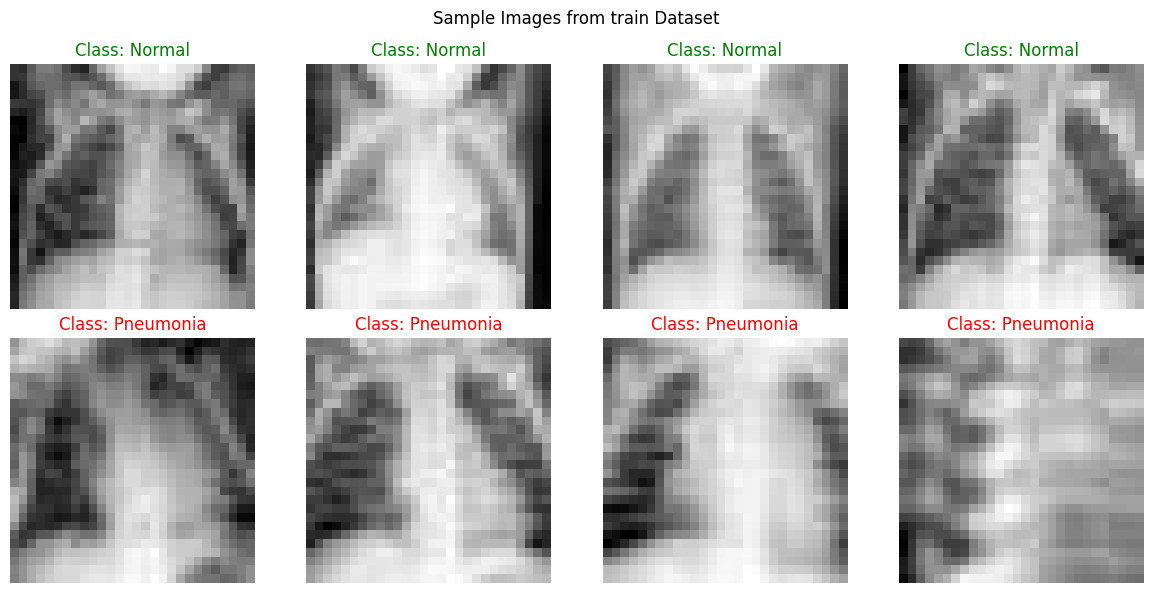

In [27]:
def show_sample_images(data, labels):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()

    # Get indices for each class
    normal_idx = np.where(labels == 0)[0]
    pneumonia_idx = np.where(labels == 1)[0]

    # Select 4 from each class
    selected_normal = np.random.choice(normal_idx, 4, replace=False)
    selected_pneumonia = np.random.choice(pneumonia_idx, 4, replace=False)

    # Combine and shuffle
    selected_indices = list(selected_normal) + list(selected_pneumonia)
    np.random.shuffle(selected_indices)

    # Display images
    for idx, ax in enumerate(axes):
        img_idx = selected_indices[idx]
        img = data[img_idx].squeeze()
        label = labels[img_idx]

        ax.imshow(img, cmap='gray')
        ax.set_title(f'Class: {"Pneumonia" if label==1 else "Normal"}',color='red' if label==1 else 'green')
        ax.axis('off')

    plt.suptitle('Sample Images from train Dataset')
    plt.tight_layout()
    plt.show()

# Call the function
show_sample_images(train_data_np, train_labels_np)

**Pixel Intensity Distribution**

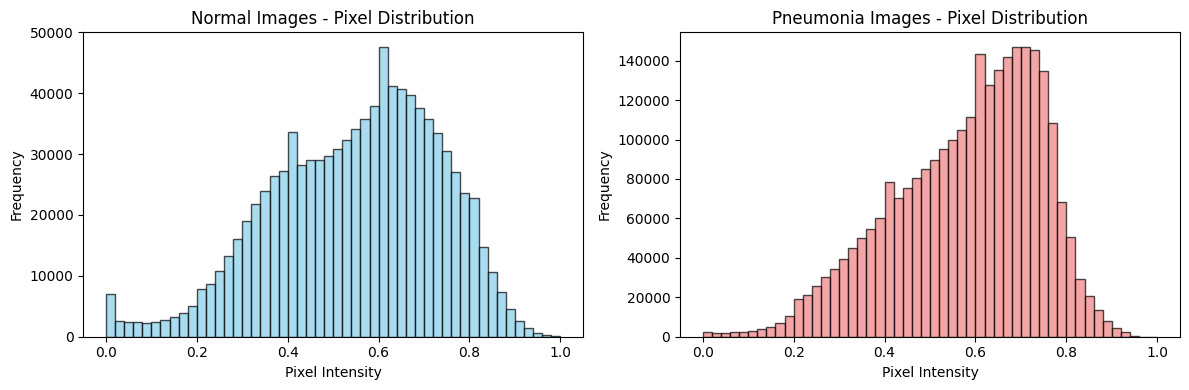

In [30]:
def analyze_image_stats(data, labels):
    normal_data = data[labels == 0]
    pneumonia_data = data[labels == 1]

    stats = {}
    for name, class_data in [('Normal', normal_data), ('Pneumonia', pneumonia_data)]:
        if len(class_data) > 0:
            stats[name] = {
                'Mean': class_data.mean(),
                'Std': class_data.std(),
                'Min': class_data.min(),
                'Max': class_data.max(),
                'Median': np.median(class_data)}
    return stats

train_stats = analyze_image_stats(train_data_np, train_labels_np)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

normal_pixels = train_data_np[train_labels_np == 0].flatten()
axes[0].hist(normal_pixels, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('Normal Images - Pixel Distribution')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')

pneumonia_pixels = train_data_np[train_labels_np == 1].flatten()
axes[1].hist(pneumonia_pixels, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].set_title('Pneumonia Images - Pixel Distribution')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()